In [6]:

import matplotlib.pyplot as plt
from pathlib import Path


from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "782149"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=DATA_DIR / pairwise_asset_name,
        source_dataset=dataset,   # delegates zarr / segmentation calls
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-03-06_12-00-00  →  ✓ attached
mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channel

In [5]:
spots_df_all_um = pw_ds.load_all_rounds_spots_mp(table_type='unmixed_spots',remove_fg_bg_cols=False)
# add rd_ch_unmixed_gene column if dont exists: "round" - "unmixed_chan" - "unmixed_gene"
if 'rd_ch_unmixed_gene' not in spots_df_all_um.columns:
    spots_df_all_um['rd_ch_unmixed_gene'] = (
        spots_df_all_um["round"] + "-" +
        spots_df_all_um["unmixed_chan"] + "-" +
        spots_df_all_um["unmixed_gene"]
    )

Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R2: 782149_R2

Loading unmixed_spots for round R3: 782149_R3


Loading unmixed_spots for round R4: 782149_R4
Loading unmixed_spots for round R5: 782149_R5


Number of unmixed_spots: 2.927e+07


In [7]:
#subsample spots_df
subsampled_spots_df = spots_df_all_um.sample(frac=0.05, random_state=42)
print(f"len(subsampled_spots_df): {len(subsampled_spots_df)}")
print(subsampled_spots_df.columns)

len(subsampled_spots_df): 1463674
Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene',
       'chan_514_intensity', 'chan_638_intensity', 'rd_ch_unmixed_gene'],
      dtype='str')


## Spot Int Violin

In [13]:
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins

# "round_chan": x = Rx-NNN-Gene sorted by round then channel, colored by channel
# use saveable

filename = f"{MOUSE_ID}_intensity_violins_round_chan"
output_dir = Path("/root/capsule/results")
ax = plot_intensity_violins(subsampled_spots_df, order="round_chan",intensity_threshold=25.0,save=True,filename=filename,output_dir=output_dir)


# "alpha": x = gene name sorted alphabetically
# plot_intensity_violins(spots_df_all_um, order="alpha")


       unmixed_chan round  chan_488_intensity  chan_514_intensity  \
0               561    R5           11.414635           73.138206   
1               561    R5            6.642270           23.756096   
2               561    R5            7.983740           45.666672   
3               561    R5            4.235770           29.869921   
4               561    R5            8.138214           24.154461   
...             ...   ...                 ...                 ...   
109995          638    R3            7.585365           13.544716   
109996          638    R3           20.577240            9.642270   
109997          638    R3           19.211380           79.715446   
109998          638    R3           10.569110           54.097561   
109999          638    R3           22.764219           16.682930   

        chan_561_intensity  chan_594_intensity  chan_638_intensity  _intensity  
0               539.837402           21.560970           12.471540  539.837402  
1        

KeyError: "['rd_ch_unmixed_gene'] not in index"

In [11]:
subsampled_spots_df["rd_ch_unmixed_gene"]

25066039        R5-561-Cck
25568522        R5-561-Cck
11254106      R2-561-Pthlh
727599          R1-488-GFP
22530238       R4-638-Gad2
                 ...      
4805314     R1-561-Slc17a7
18948067      R4-488-Lamp5
6812672     R1-561-Slc17a7
18264124      R4-488-Lamp5
18214346      R4-488-Lamp5
Name: rd_ch_unmixed_gene, Length: 1463674, dtype: str

Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R2: 782149_R2
Loading unmixed_spots for round R3: 782149_R3


Loading unmixed_spots for round R4: 782149_R4
Loading unmixed_spots for round R5: 782149_R5



Number of unmixed_spots: 2.927e+07
columns: ['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id', 'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity', 'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot', 'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene', 'chan_514_intensity', 'chan_638_intensity', 'rd_ch_unmixed_gene']
       unmixed_chan round rd_ch_unmixed_gene  chan_488_intensity  \
0               561    R5         R5-561-Cck           11.024390   
1               561    R5         R5-561-Cck           11.390240   
2               561    R5         R5-561-Cck            7.658540   
3               561    R5         R5-561-Cck           22.520325   
4               561    R5         R5-56

/src/aind-hcr-qc/src/aind_hcr_qc/utils/utils.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  


<Axes: title={'center': 'Spot intensities by round–channel–gene'}, xlabel='Round – Channel – Gene', ylabel='Intensity (log scale)'>

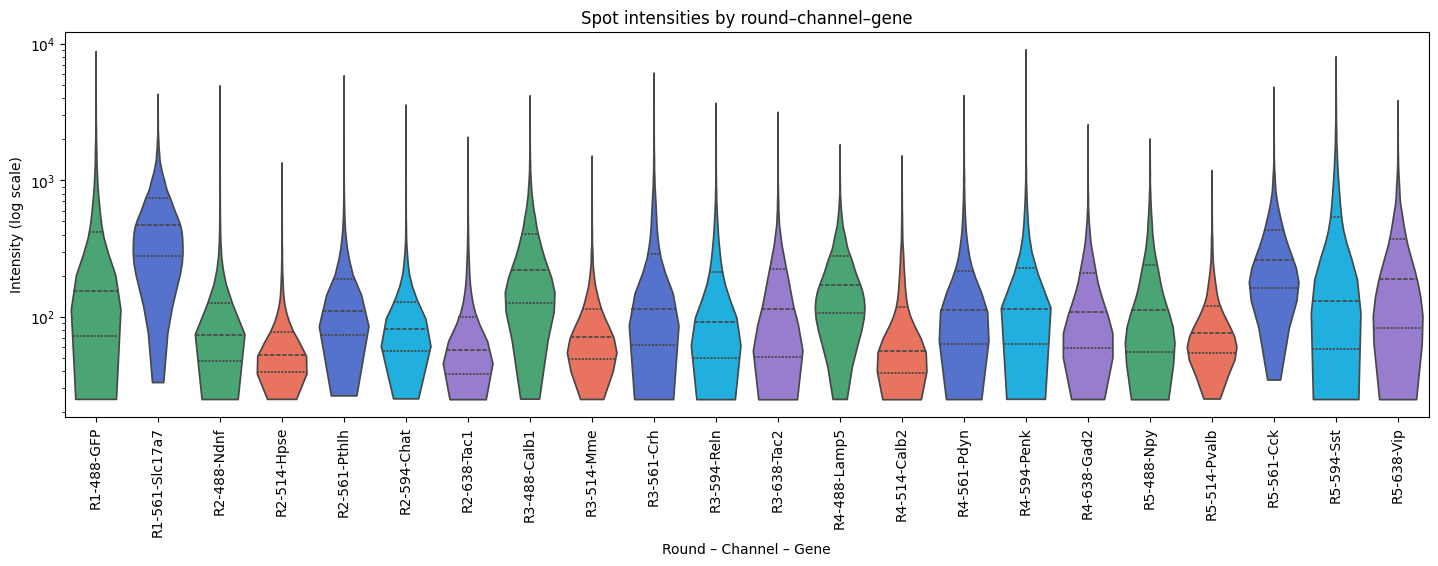

In [15]:

# Reproduce: add column fresh and pass directly to plot
_df = pw_ds.load_all_rounds_spots_mp(table_type='unmixed_spots', remove_fg_bg_cols=False)
_df['rd_ch_unmixed_gene'] = (
    _df["round"] + "-" +
    _df["unmixed_chan"] + "-" +
    _df["unmixed_gene"]
)
print("columns:", _df.columns.tolist())
plot_intensity_violins(_df.sample(frac=0.05, random_state=42), order="round_chan", intensity_threshold=25.0)
